# Entrenamiento: Detector de Odómetro

Notebook para el entrenamiento iterativo del Detector de Odómetro (YOLO OBB) para localización de odómetros mecánicos en medidores de agua.

## Dataset

- **Fuente**: `data/obb/` (construido por `scripts/build/build_obb.py`)
- **Imágenes**: 1,199 (resolución nativa 960×1280 o 1280×960)
- **Split estratificado**: 959 train / 120 val / 120 test (80/10/10)
- **Estratificación**: por background (bgwhite/bgblack), n_digits, has_decimal
- **Clase única**: `Odometer`

## Diseño de Experimentos

Se sigue un diseño iterativo de **una variable a la vez** con selección greedy sobre val:

| Iteración | Parámetro | Cambio | Objetivo |
|---|---|---|---|
| **Baseline** | `model=yolov8n-obb`, `imgsz=640`, `epochs=100` | — | Punto de referencia |
| Iter 1 | `imgsz` | 640 → 1280 | Evitar downscaling severo |
| Iter 2 | `model` | yolov8n → yolov8s o m | Mayor capacidad |
| Iter 3 | `model` | yolov8 → yolo11 | Mejor arquitectura |
| Iter 4 | `copy_paste` | 0 → 0.3 | Augmentation tuning |
| Iter 5 | `epochs` | 100 → 200 | Convergencia (losses no convergieron en 100) |

**Métrica principal**: mAP50-95 (rotated IoU). Val para decisiones, test solo al final.

---

## PARTE 1: CONFIGURACIÓN DEL ENTORNO

### 1.1 Verificar GPU disponible

In [1]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("ADVERTENCIA: No se detecto GPU. Ve a Runtime > Change runtime type > GPU")

PyTorch version: 2.10.0+cu128
CUDA disponible: True
GPU: Tesla T4
CUDA version: 12.8
Memoria GPU: 15.64 GB


### 1.2 Instalar Ultralytics

In [2]:
!pip install -q ultralytics

from ultralytics import YOLO
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.21


### 1.3 Montar Google Drive

**IMPORTANTE:** Antes de ejecutar esta celda, sube `data/obb/` a tu Google Drive.

La estructura esperada en Drive es:
```
MyDrive/water-meter-training/
├── data/
│   └── obb/                           # Construido por scripts/build/build_obb.py
│       ├── images/{train,val,test}/
│       ├── labels/{train,val,test}/
│       └── data.yaml
│
└── odometer-detector/                 # Generado por este notebook
    ├── dataset/                       # Copia local del dataset
    ├── runs/                          # YOLO output (un dir por iteración)
    │   ├── baseline/
    │   ├── iter1-imgsz/
    │   └── ...
    └── export/                        # Artefactos exportados por iteración
        ├── baseline/
        │   ├── best.pt
        │   ├── summary.md
        │   ├── training_config.yaml
        │   ├── results.csv
        │   └── metrics/
        ├── iter1-imgsz/
        │   └── ...
        └── {ganador}/                 # El ganador final además incluye:
            └── formats/               #   ONNX, TorchScript (celda 6.2)
```

In [3]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

DRIVE_MOUNT_PATH = '/content/drive/MyDrive/water-meter-training'

if os.path.exists(f'{DRIVE_MOUNT_PATH}/data/obb'):
    print(f"Dataset OBB encontrado en: {DRIVE_MOUNT_PATH}/data/obb")
else:
    print(f"ADVERTENCIA: No se encontro data/obb/ en {DRIVE_MOUNT_PATH}")
    print("Sube data/obb/ a Drive antes de continuar")

Mounted at /content/drive
Dataset OBB encontrado en: /content/drive/MyDrive/water-meter-training/data/obb


### 1.4 Configuración de Rutas del Proyecto

In [4]:
# =====================================================
# CONFIGURACION DE RUTAS
# =====================================================

DRIVE_BASE = '/content/drive/MyDrive/water-meter-training'

# Dataset fuente (construido por scripts/build/build_obb.py)
SOURCE_DATASET_PATH = f'{DRIVE_BASE}/data/obb'

# Componente: odometer-detector
COMPONENT_DIR = f'{DRIVE_BASE}/odometer-detector'
RESULTS_DIR = f'{COMPONENT_DIR}/runs'
EXPORT_DIR = f'{COMPONENT_DIR}/export'

# Workspace local (dataset copiado con rutas absolutas)
DATASET_PATH = f'{COMPONENT_DIR}/dataset'

# =====================================================
# Rutas derivadas (no modificar)
# =====================================================
TRAIN_IMAGES = f'{DATASET_PATH}/images/train'
TRAIN_LABELS = f'{DATASET_PATH}/labels/train'
VAL_IMAGES = f'{DATASET_PATH}/images/val'
VAL_LABELS = f'{DATASET_PATH}/labels/val'
TEST_IMAGES = f'{DATASET_PATH}/images/test'
TEST_LABELS = f'{DATASET_PATH}/labels/test'
DATA_YAML = f'{DATASET_PATH}/data.yaml'

# Crear directorios
os.makedirs(COMPONENT_DIR, exist_ok=True)

print("=== CONFIGURACION DE RUTAS ===")
print(f"Dataset fuente:  {SOURCE_DATASET_PATH}")
print(f"Componente:      {COMPONENT_DIR}")
print(f"  dataset/       {DATASET_PATH}")
print(f"  runs/          {RESULTS_DIR}")
print(f"  export/        {EXPORT_DIR}")

=== CONFIGURACION DE RUTAS ===
Dataset fuente:  /content/drive/MyDrive/water-meter-training/data/obb
Componente:      /content/drive/MyDrive/water-meter-training/odometer-detector
  dataset/       /content/drive/MyDrive/water-meter-training/odometer-detector/dataset
  runs/          /content/drive/MyDrive/water-meter-training/odometer-detector/runs
  export/        /content/drive/MyDrive/water-meter-training/odometer-detector/export


### 1.5 Importar bibliotecas necesarias

In [5]:
import os
import glob
import shutil
import random
from pathlib import Path
from datetime import datetime
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

# Fijar semilla para reproducibilidad
random.seed(42)
np.random.seed(42)

IMG_EXTS = ('.jpg', '.jpeg', '.png')

def count_images(directory):
    """Cuenta imágenes en un directorio."""
    return len([f for f in os.listdir(directory) if f.lower().endswith(IMG_EXTS)])

print("Bibliotecas importadas correctamente")

Bibliotecas importadas correctamente


---

## PARTE 2: PREPARACIÓN DEL DATASET

### 2.1 Copiar Dataset a Workspace

Copia `data/obb/` desde Drive al workspace de entrenamiento. El dataset ya incluye el split estratificado (train/val/test) y `data.yaml`.

In [ ]:
# Copiar dataset a workspace (si no existe ya)
needs_copy = not os.path.exists(DATASET_PATH) or not os.path.exists(DATA_YAML)

# Verificar que las imágenes realmente estén copiadas (no solo labels)
if not needs_copy:
    for split in ['train', 'val', 'test']:
        img_dir = f'{DATASET_PATH}/images/{split}'
        if not os.path.exists(img_dir) or count_images(img_dir) == 0:
            needs_copy = True
            print(f"Directorio vacio o faltante: {img_dir}")
            break

if needs_copy:
    if not os.path.exists(SOURCE_DATASET_PATH):
        raise FileNotFoundError(f"Dataset fuente no encontrado: {SOURCE_DATASET_PATH}")

    # Limpiar destino si existe parcialmente
    if os.path.exists(DATASET_PATH):
        shutil.rmtree(DATASET_PATH)

    print(f"Copiando {SOURCE_DATASET_PATH} → {DATASET_PATH} ...")
    shutil.copytree(SOURCE_DATASET_PATH, DATASET_PATH)
    print("Copia completada")
else:
    print("Dataset ya existe en workspace, omitiendo copia")

# Verificar estructura
SPLITS = ['train', 'val', 'test']
print("\n=== DATASET EN WORKSPACE ===")
total = 0
for split in SPLITS:
    img_dir = f'{DATASET_PATH}/images/{split}'
    lbl_dir = f'{DATASET_PATH}/labels/{split}'
    n_imgs = count_images(img_dir)
    n_lbls = len([f for f in os.listdir(lbl_dir) if f.endswith('.txt')])
    print(f"  {split:5s}: {n_imgs} images, {n_lbls} labels")
    assert n_imgs == n_lbls, f"Mismatch en {split}: {n_imgs} imgs vs {n_lbls} labels"
    total += n_imgs

print(f"  Total: {total}")
assert os.path.exists(DATA_YAML), f"data.yaml no encontrado en {DATASET_PATH}"
print(f"\ndata.yaml: {DATA_YAML}")

Dataset ya existe en workspace, omitiendo copia

=== DATASET EN WORKSPACE ===
  train: 959 images, 959 labels
  val  : 120 images, 120 labels
  test : 120 images, 120 labels
  Total: 1199

data.yaml: /content/drive/MyDrive/water-meter-training/odometer-detector/dataset/data.yaml


### 2.2 Preparar data.yaml con Rutas Absolutas

El `data.yaml` original usa rutas relativas. Lo parchamos con rutas absolutas del workspace para compatibilidad con Ultralytics.

In [ ]:
# Parchear data.yaml con rutas absolutas
with open(DATA_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

data_config['path'] = DATASET_PATH
data_config['train'] = 'images/train'
data_config['val'] = 'images/val'
data_config['test'] = 'images/test'

with open(DATA_YAML, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("data.yaml actualizado con rutas absolutas:")
print(yaml.dump(data_config, default_flow_style=False))

data.yaml actualizado con rutas absolutas:
names:
  0: Odometer
path: /content/drive/MyDrive/water-meter-training/odometer-detector/dataset
test: images/test
train: images/train
val: images/val



---

## PARTE 3: CONFIGURACIÓN DEL MODELO (BASELINE)

### 3.1 Selección del Modelo

El baseline usa el modelo más pequeño. Iteraciones posteriores escalarán el modelo según los resultados.

| Modelo | Parámetros | Iteración |
|--------|------------|-----------|
| **yolov8n-obb** | 3.2M | **Baseline** |
| yolov8s-obb | 11.2M | Iter 2 (si n no es suficiente) |
| yolov8m-obb | 25.9M | Iter 2 (alternativa) |
| yolo11s-obb | — | Iter 3 (architecture upgrade) |

In [ ]:
# =====================================================
# MODELO — Modificar para cada iteración
# =====================================================
MODEL_NAME = 'yolov8n-obb.pt'  # Baseline: yolov8n | Iter 2: yolov8s (reverted) | Iter 3: yolo11n (reverted)

print(f"Modelo: {MODEL_NAME}")

Modelo: yolov8n-obb.pt


### 3.2 Hiperparámetros de Entrenamiento (Baseline)

Valores baseline per tech doc. Cada iteración cambiará **una sola variable**.

In [6]:
# =====================================================
# HIPERPARAMETROS — Modificar para cada iteración
# =====================================================

RUN_NAME = 'baseline'  # baseline, iter1-imgsz, iter2-arch, iter3-yolo11, iter4-aug, iter5-conv
RUN_DESCRIPTION = 'YOLOv8n-OBB, 640px, epochs=100 (configuración ganadora — evaluación final en test set)'

EPOCHS = 100       # Baseline: 100 | Iter 5: 200
IMG_SIZE = 640     # Baseline: 640 (iter1 revertida)
BATCH_SIZE = 16    # Ajustar según GPU (8 si hay problemas de memoria)
PATIENCE = 50      # Early stopping

print("=== HIPERPARAMETROS ===")
print(f"  Run:       {RUN_NAME}")
print(f"  Desc:      {RUN_DESCRIPTION}")
print(f"  Epochs:    {EPOCHS}")
print(f"  Img size:  {IMG_SIZE}")
print(f"  Batch:     {BATCH_SIZE}")
print(f"  Patience:  {PATIENCE}")

=== HIPERPARAMETROS ===
  Run:       baseline
  Desc:      YOLOv8n-OBB, 640px, epochs=100 (configuración ganadora — evaluación final en test set)
  Epochs:    100
  Img size:  640
  Batch:     16
  Patience:  50


### 3.3 Augmentaciones

El baseline usa los defaults de YOLO (sin override). En **Iter 4** se ajustó `copy_paste` directamente en la celda de entrenamiento (4.2).

---

## PARTE 4: ENTRENAMIENTO

### 4.1 Inicializar Modelo

In [ ]:
model = YOLO(MODEL_NAME)

print(f"Modelo {MODEL_NAME} cargado")
print(f"Dispositivo: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

Modelo yolov8n-obb.pt cargado
Dispositivo: CUDA


### 4.2 Ejecutar Entrenamiento

Los resultados se guardan en Google Drive. El entrenamiento puede tomar 30-60 min dependiendo de la GPU.

In [ ]:
print(f"Iniciando entrenamiento: {RUN_NAME}")
print(f"  {RUN_DESCRIPTION}")
print(f"  Resultados en: {RESULTS_DIR}/detect/{RUN_NAME}")
print("=" * 50)

results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    patience=PATIENCE,
    device=0 if torch.cuda.is_available() else 'cpu',
    project=RESULTS_DIR,
    name=RUN_NAME,
    exist_ok=True,

    # --- Iter 4 (revertida): augmentation tuning ---
    # copy_paste=0.3,

    amp=True,
    save=True,
    save_period=10,
    plots=True,
    verbose=True,
    resume=False  # change to True to resume the training
)

print("\n" + "=" * 50)
print("Entrenamiento completado!")
print(f"Mejor modelo: {results.save_dir}/weights/best.pt")

Iniciando entrenamiento: iter5-conv
  YOLOv8n-OBB, 640px, epochs=200 (convergence tuning — losses no convergieron en baseline)
  Resultados en: /content/drive/MyDrive/water-meter-training/odometer-detector/runs/detect/iter5-conv
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/water-meter-training/odometer-detector/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kob

---

## PARTE 5: RESULTADOS Y EVALUACIÓN

### 5.1 Cargar Mejor Modelo

In [7]:
# Localizar la corrida actual
RUN_PATH = f'{RESULTS_DIR}/{RUN_NAME}'

if os.path.exists(RUN_PATH):
    print(f"Corrida encontrada: {RUN_NAME}")
    print(f"  Ruta: {RUN_PATH}")
else:
    print(f"ERROR: No se encontro la corrida '{RUN_NAME}' en {RESULTS_DIR}")
    print("Ejecuta la celda de entrenamiento (4.2) primero")
    RUN_PATH = None

Corrida encontrada: baseline
  Ruta: /content/drive/MyDrive/water-meter-training/odometer-detector/runs/baseline


In [8]:
# Cargar el mejor modelo
if RUN_PATH:
    best_model_path = f'{RUN_PATH}/weights/best.pt'

    if os.path.exists(best_model_path):
        model_best = YOLO(best_model_path)
        print(f"Modelo cargado desde: {best_model_path}")
    else:
        print(f"ERROR: No se encontro best.pt en {RUN_PATH}/weights/")
        model_best = None
else:
    model_best = None

Modelo cargado desde: /content/drive/MyDrive/water-meter-training/odometer-detector/runs/baseline/weights/best.pt


### 5.2 Métricas en Test Set (evaluación final)

Evaluación única sobre test set con el modelo ganador (baseline). Métricas:
- **mAP50-95** (principal): discrimina mejor entre iteraciones que mAP50
- **mAP50** (complementaria): comparabilidad con literatura
- **Precision / Recall** (complementarias): detectar regresiones

In [9]:
# Ejecutar evaluación sobre test set (una sola vez, con modelo ganador)
if model_best:
    print("Ejecutando evaluacion en TEST set (evaluacion final)...")
    metrics = model_best.val(
        data=DATA_YAML,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        device=0 if torch.cuda.is_available() else 'cpu',
        split='test',
        plots=True,
    )

    print("\n" + "=" * 50)
    print("=== METRICAS DE TEST (evaluacion final) ===")
    print("=" * 50)
    print(f"  mAP50-95:  {metrics.box.map:.4f}  ← metrica principal")
    print(f"  mAP50:     {metrics.box.map50:.4f}")
    print(f"  Precision: {metrics.box.mp:.4f}")
    print(f"  Recall:    {metrics.box.mr:.4f}")
    print("=" * 50)
else:
    print("No hay modelo cargado para validar")

Ejecutando evaluacion en TEST set (evaluacion final)...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-obb summary (fused): 82 layers, 3,077,414 parameters, 0 gradients, 8.3 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.1 ms, read: 0.2±0.1 MB/s, size: 217.7 KB)
val: Scanning /content/drive/MyDrive/water-meter-training/odometer-detector/dataset/labels/test... 120 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 120/120 1.7s/it 3:26
val: New cache created: /content/drive/MyDrive/water-meter-training/odometer-detector/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.0it/s 7.6s
                   all        120        120      0.992          1      0.995      0.952
Speed: 5.7ms preprocess, 7.6ms inference, 0.0ms loss, 8.8ms postprocess per image
Results saved to /content/runs/obb/val

=== METRICAS DE TEST (evaluacion final) ===
  mAP50-95:  0.9522  ← metr

### 5.3 Curvas de Entrenamiento

Verificar: train/val loss convergencia sin divergencia (overfitting) y estabilización de mAP50-95.

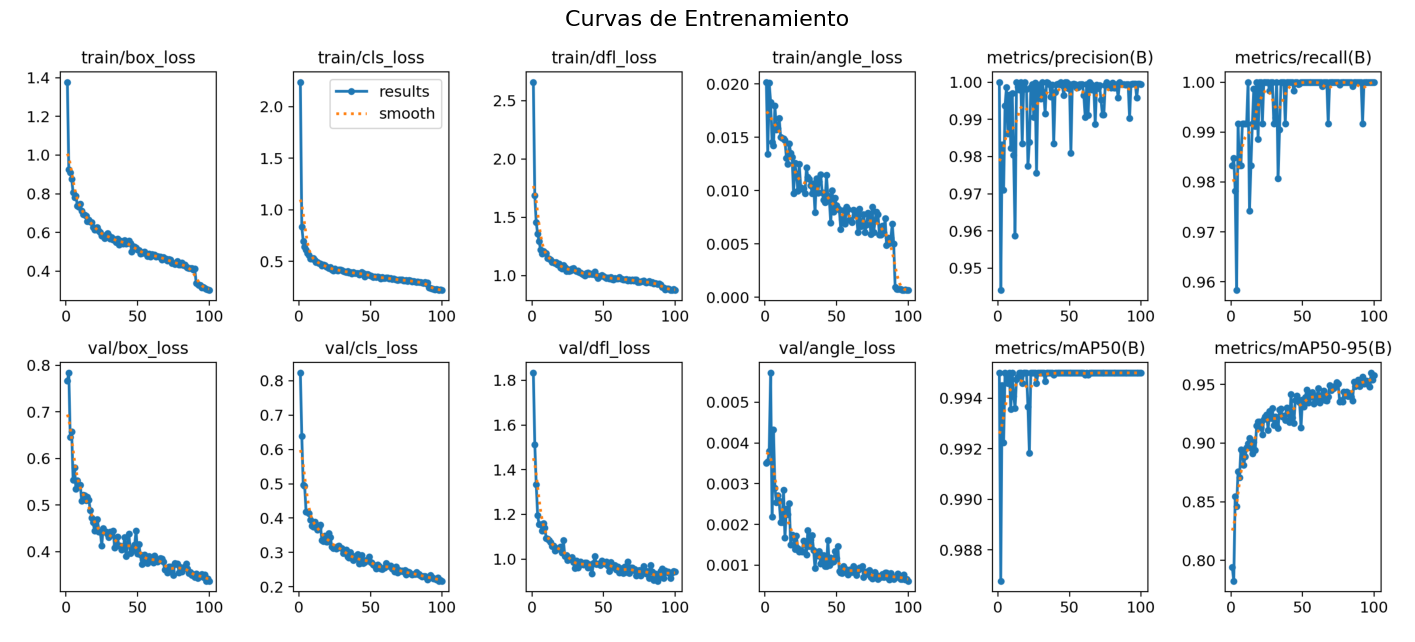

In [10]:
# Mostrar curvas de entrenamiento
if RUN_PATH:
    results_img = f'{RUN_PATH}/results.png'
    if os.path.exists(results_img):
        plt.figure(figsize=(18, 12))
        plt.imshow(Image.open(results_img))
        plt.axis('off')
        plt.title('Curvas de Entrenamiento', fontsize=16)
        plt.show()
    else:
        print(f"No se encontro results.png en {RUN_PATH}")

### 5.4 Matriz de Confusión

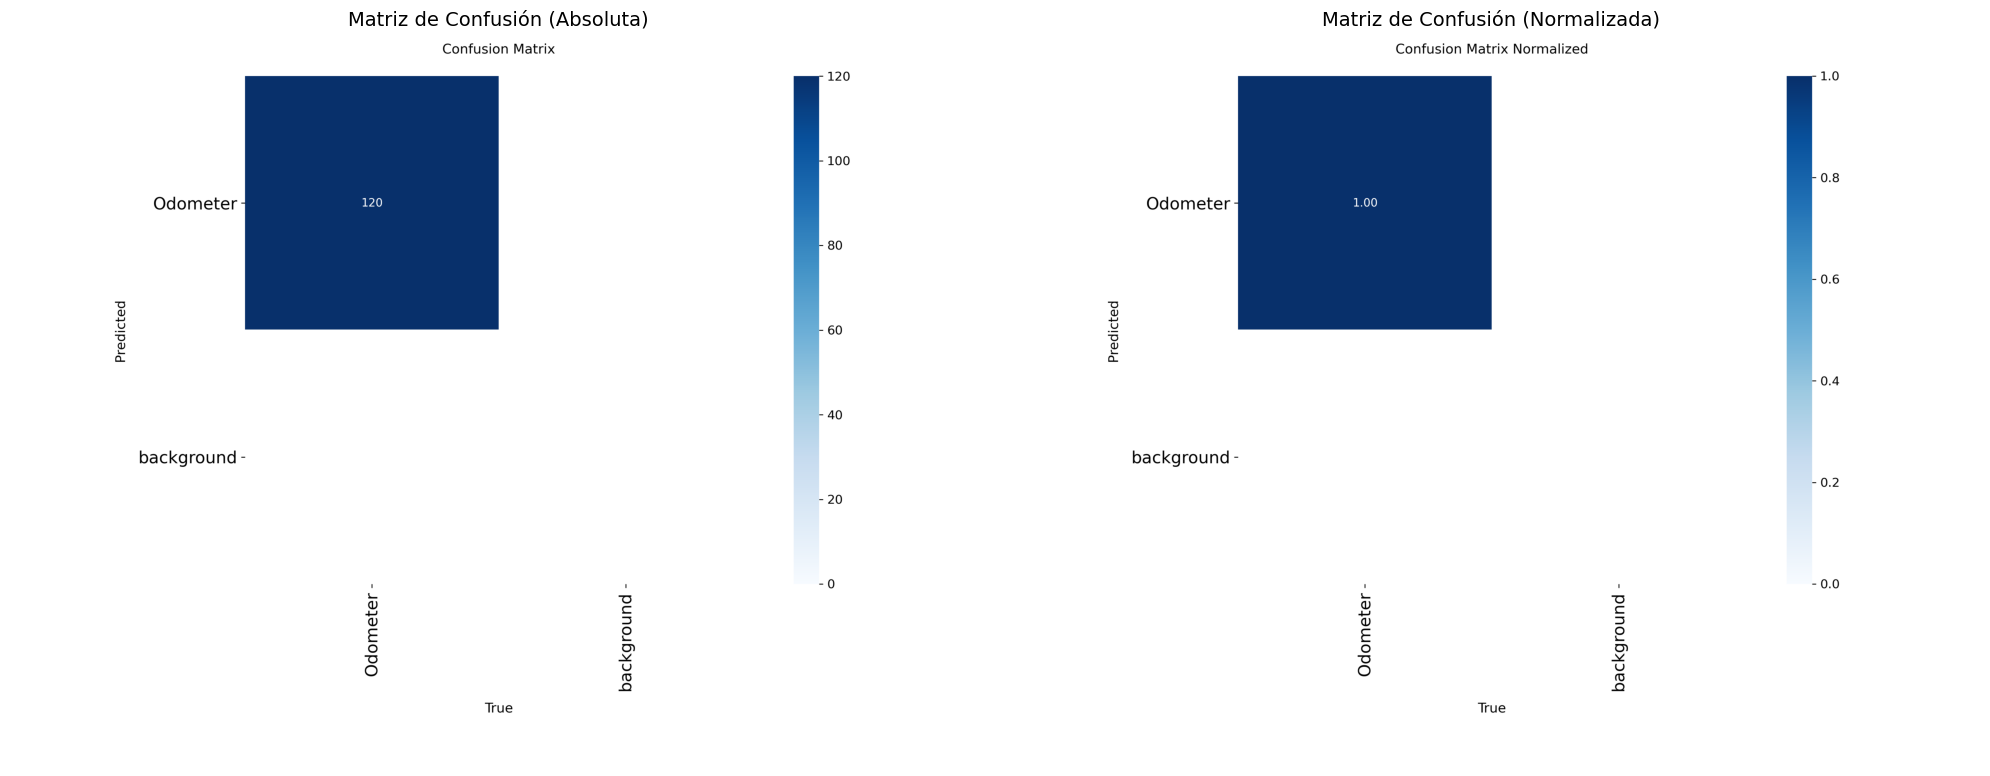

In [11]:
# Mostrar matrices de confusión (absoluta y normalizada)
if RUN_PATH:
    cm_files = [
        ('confusion_matrix.png', 'Matriz de Confusión (Absoluta)'),
        ('confusion_matrix_normalized.png', 'Matriz de Confusión (Normalizada)'),
    ]
    found = [(f'{RUN_PATH}/{f}', t) for f, t in cm_files if os.path.exists(f'{RUN_PATH}/{f}')]

    if found:
        fig, axes = plt.subplots(1, len(found), figsize=(10 * len(found), 10))
        if len(found) == 1:
            axes = [axes]
        for ax, (path, title) in zip(axes, found):
            ax.imshow(Image.open(path))
            ax.set_title(title, fontsize=14)
            ax.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No se encontraron matrices de confusión en {RUN_PATH}")

### 5.5 Curva Precision-Recall

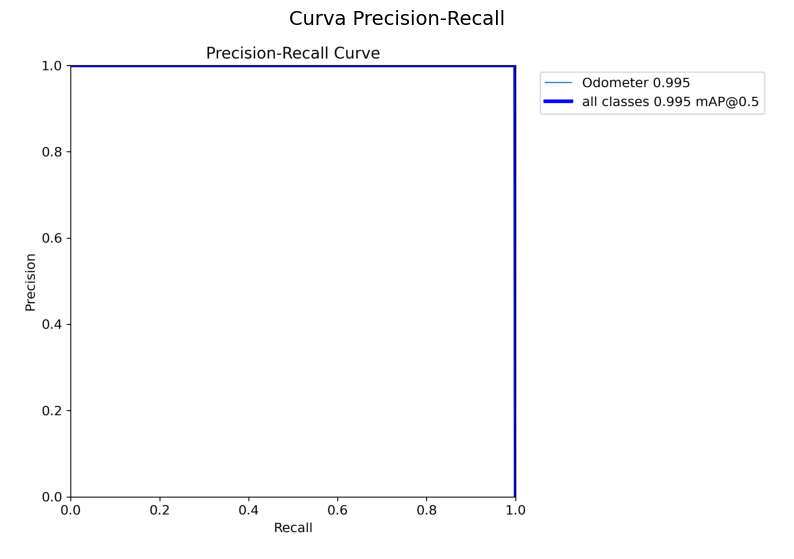

In [12]:
# Mostrar curva Precision-Recall
if RUN_PATH:
    pr_img = f'{RUN_PATH}/BoxPR_curve.png'
    if os.path.exists(pr_img):
        plt.figure(figsize=(10, 8))
        plt.imshow(Image.open(pr_img))
        plt.axis('off')
        plt.title('Curva Precision-Recall', fontsize=14)
        plt.show()
    else:
        print(f"No se encontro BoxPR_curve.png en {RUN_PATH}")

### 5.6 Predicciones en Validación (sample)

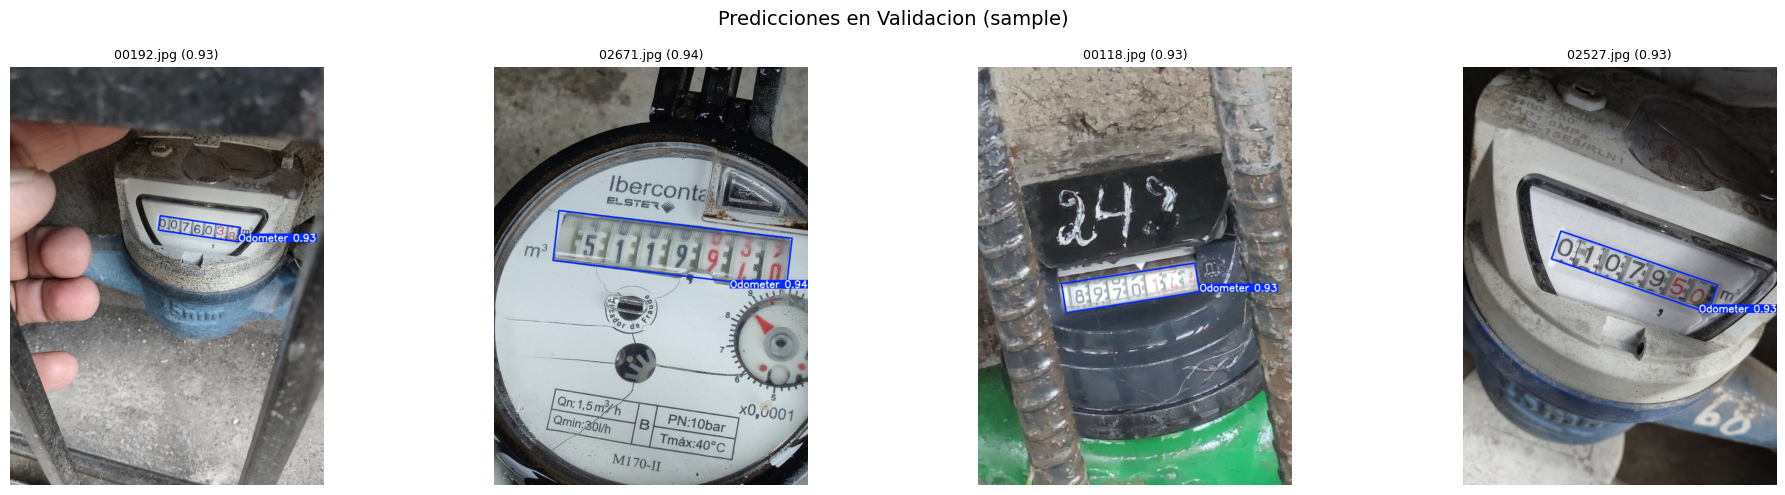

In [13]:
# Sanity check visual: 4 predicciones random en val
if model_best and os.path.exists(VAL_IMAGES):
    val_image_files = [f for f in os.listdir(VAL_IMAGES) if f.lower().endswith(IMG_EXTS)]
    sample_val = random.sample(val_image_files, min(4, len(val_image_files)))

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    for idx, img_name in enumerate(sample_val):
        img_path = f'{VAL_IMAGES}/{img_name}'
        results = model_best.predict(img_path, conf=0.25, verbose=False)

        img_result = results[0].plot()
        img_result = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

        if len(results[0].obb) > 0 and results[0].obb.conf is not None:
            conf = results[0].obb.conf[0].item()
            title = f'{img_name} ({conf:.2f})'
        else:
            title = f'{img_name} (sin det.)'

        axes[idx].imshow(img_result)
        axes[idx].set_title(title, fontsize=9)
        axes[idx].axis('off')

    plt.suptitle('Predicciones en Validacion (sample)', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No hay modelo o imagenes de validacion disponibles")

### 5.7 Resumen de Rendimiento

In [ ]:
if model_best and 'metrics' in dir():
    n_train = count_images(TRAIN_IMAGES)
    n_val = count_images(VAL_IMAGES)
    n_test = count_images(TEST_IMAGES)

    # Epochs entrenados (leer de results.csv)
    epochs_trained = 'N/A'
    try:
        results_csv = f'{RUN_PATH}/results.csv'
        if os.path.exists(results_csv):
            epochs_trained = len(pd.read_csv(results_csv))
    except Exception:
        pass

    print("\n" + "=" * 50)
    print(f"    RESUMEN: {RUN_NAME}")
    print(f"    {RUN_DESCRIPTION}")
    print("=" * 50)
    print(f"| {'Metrica':<15} | {'Valor':>10} |")
    print("-" * 32)
    print(f"| {'mAP50-95 *':<15} | {metrics.box.map:>10.4f} |")
    print(f"| {'mAP50':<15} | {metrics.box.map50:>10.4f} |")
    print(f"| {'Precision':<15} | {metrics.box.mp:>10.4f} |")
    print(f"| {'Recall':<15} | {metrics.box.mr:>10.4f} |")
    print("-" * 32)
    print(f"| {'Modelo':<15} | {MODEL_NAME:>10} |")
    print(f"| {'Img size':<15} | {IMG_SIZE:>10} |")
    print(f"| {'Train imgs':<15} | {n_train:>10} |")
    print(f"| {'Val imgs':<15} | {n_val:>10} |")
    print(f"| {'Test imgs':<15} | {n_test:>10} |")
    print(f"| {'Epochs':<15} | {str(epochs_trained):>10} |")
    print("=" * 50)
    print("* metrica principal para seleccion greedy")
else:
    print("No hay metricas disponibles. Ejecuta la validacion primero.")

---

## PARTE 6: EXPORTAR MODELO

### 6.1 Exportar artefactos de la iteración

Genera `export/{RUN_NAME}/` con los artefactos de esta iteración. **No borra iteraciones anteriores.**

```
export/
├── baseline/                    ← RUN_NAME
│   ├── best.pt
│   ├── summary.md              ← Resumen legible de la iteración
│   ├── training_config.yaml
│   ├── results.csv
│   └── metrics/
├── iter1-imgsz/
│   └── ...
└── iter2-arch/
    └── ...
```

Para el **modelo ganador final**, copiar `export/{ganador}/` → `models/odometer-detector/` en el repo local.

In [ ]:
if RUN_PATH:
    # Directorio de esta iteración (no borra las anteriores)
    run_export_dir = f'{EXPORT_DIR}/{RUN_NAME}'
    if os.path.exists(run_export_dir):
        shutil.rmtree(run_export_dir)
    os.makedirs(run_export_dir)
    metrics_export_dir = f'{run_export_dir}/metrics'
    os.makedirs(metrics_export_dir)

    # 1. Copiar best.pt
    best_src = f'{RUN_PATH}/weights/best.pt'
    if os.path.exists(best_src):
        shutil.copy(best_src, f'{run_export_dir}/best.pt')
        print("Copiado: best.pt")
    else:
        print(f"ADVERTENCIA: best.pt no encontrado en {RUN_PATH}/weights/")

    # 2. Copiar métricas y gráficas
    METRIC_FILES = [
        'results.png', 'results.csv', 'args.yaml',
        'confusion_matrix.png', 'confusion_matrix_normalized.png',
        'BoxPR_curve.png', 'BoxF1_curve.png', 'BoxP_curve.png', 'BoxR_curve.png',
        'labels.jpg',
    ]
    METRIC_PATTERNS = ['val_batch*_labels.jpg', 'val_batch*_pred.jpg']

    copied_metrics = []
    for fname in METRIC_FILES:
        src = f'{RUN_PATH}/{fname}'
        if os.path.exists(src):
            shutil.copy(src, f'{metrics_export_dir}/{fname}')
            copied_metrics.append(fname)

    for pattern in METRIC_PATTERNS:
        for src in glob.glob(f'{RUN_PATH}/{pattern}'):
            fname = os.path.basename(src)
            shutil.copy(src, f'{metrics_export_dir}/{fname}')
            copied_metrics.append(fname)

    # Copiar results.csv también a nivel raíz (acceso rápido)
    if os.path.exists(f'{RUN_PATH}/results.csv'):
        shutil.copy(f'{RUN_PATH}/results.csv', f'{run_export_dir}/results.csv')

    print(f"Copiados {len(copied_metrics)} archivos a metrics/")

    # 3. Leer epochs entrenados
    epochs_trained = 'N/A'
    try:
        if os.path.exists(f'{RUN_PATH}/results.csv'):
            epochs_trained = len(pd.read_csv(f'{RUN_PATH}/results.csv'))
    except Exception:
        pass

    # 4. Generar training_config.yaml
    training_config = {
        'run': {
            'name': RUN_NAME,
            'description': RUN_DESCRIPTION,
        },
        'model': {
            'weights': MODEL_NAME,
        },
        'training': {
            'epochs_configured': EPOCHS,
            'epochs_trained': epochs_trained,
            'img_size': IMG_SIZE,
            'batch_size': BATCH_SIZE,
            'patience': PATIENCE,
        },
        'dataset': {
            'train_images': count_images(TRAIN_IMAGES),
            'val_images': count_images(VAL_IMAGES),
            'test_images': count_images(TEST_IMAGES),
        },
        'metadata': {
            'exported_on': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        },
    }

    if 'metrics' in dir() and metrics is not None:
        training_config['metrics'] = {
            'mAP50-95': round(float(metrics.box.map), 4),
            'mAP50': round(float(metrics.box.map50), 4),
            'precision': round(float(metrics.box.mp), 4),
            'recall': round(float(metrics.box.mr), 4),
        }

    with open(f'{run_export_dir}/training_config.yaml', 'w') as f:
        yaml.dump(training_config, f, default_flow_style=False, sort_keys=False)
    print("Generado: training_config.yaml")

    # 5. Generar summary.md
    summary_lines = [
        f'# {RUN_NAME} — Detector de Odómetro',
        f'> {RUN_DESCRIPTION}',
        '',
        f'- **Fecha**: {datetime.now().strftime("%Y-%m-%d")}',
        f'- **Modelo**: {MODEL_NAME}',
        f'- **Epochs**: {EPOCHS} (entrenados: {epochs_trained})',
        f'- **Img size**: {IMG_SIZE}',
        f'- **Batch**: {BATCH_SIZE}',
        f'- **Patience**: {PATIENCE}',
    ]

    if 'metrics' in dir() and metrics is not None:
        summary_lines += [
            '',
            '## Métricas (val)',
            '',
            f'- **mAP50-95: {metrics.box.map:.4f}** (principal)',
            f'- mAP50: {metrics.box.map50:.4f}',
            f'- Precision: {metrics.box.mp:.4f}',
            f'- Recall: {metrics.box.mr:.4f}',
        ]

    summary_lines += [
        '',
        '## Archivos',
        '',
        '- `best.pt` — Mejor checkpoint',
        '- `training_config.yaml` — Configuración completa',
        '- `results.csv` — Métricas por epoch',
        '- `metrics/` — Gráficas de entrenamiento',
    ]

    with open(f'{run_export_dir}/summary.md', 'w', encoding='utf-8') as f:
        f.write('\n'.join(summary_lines) + '\n')
    print("Generado: summary.md")

    # Resumen
    print(f"\n{'=' * 50}")
    print(f"EXPORT: {run_export_dir}")
    print(f"{'=' * 50}")
    for root, dirs, files in os.walk(run_export_dir):
        level = root.replace(run_export_dir, '').count(os.sep)
        indent = '  ' * level
        folder = os.path.basename(root)
        if level > 0:
            print(f"{indent}{folder}/")
        for f in sorted(files):
            print(f"{indent}  {f}")

    # Mostrar todas las iteraciones exportadas
    all_exports = sorted([d for d in os.listdir(EXPORT_DIR)
                          if os.path.isdir(f'{EXPORT_DIR}/{d}')])
    if len(all_exports) > 1:
        print(f"\n--- Iteraciones exportadas ({len(all_exports)}) ---")
        for exp in all_exports:
            print(f"  {exp}/")
else:
    print("No hay corrida de entrenamiento para exportar")

Copiado: best.pt
Copiados 16 archivos a metrics/
Generado: training_config.yaml
Generado: summary.md

EXPORT: /content/drive/MyDrive/water-meter-training/odometer-detector/export/iter5-conv
  best.pt
  results.csv
  summary.md
  training_config.yaml
  metrics/
    BoxF1_curve.png
    BoxPR_curve.png
    BoxP_curve.png
    BoxR_curve.png
    args.yaml
    confusion_matrix.png
    confusion_matrix_normalized.png
    labels.jpg
    results.csv
    results.png
    val_batch0_labels.jpg
    val_batch0_pred.jpg
    val_batch1_labels.jpg
    val_batch1_pred.jpg
    val_batch2_labels.jpg
    val_batch2_pred.jpg

--- Iteraciones exportadas (7) ---
  alt_baseline/
  baseline/
  iter1-imgsz/
  iter2-arch/
  iter3-yolo11/
  iter4-aug/
  iter5-conv/


### 6.2 Exportar a ONNX / TorchScript (opcional)

Ejecutar **solo con el modelo ganador final**. Genera formatos optimizados para inferencia en `export/{RUN_NAME}/formats/`.

In [ ]:
# Exportar a ONNX y TorchScript (descomentar cuando se tenga el modelo final)

# if model_best and os.path.exists(f'{EXPORT_DIR}/{RUN_NAME}'):
#     formats_dir = f'{EXPORT_DIR}/{RUN_NAME}/formats'
#     os.makedirs(formats_dir, exist_ok=True)
#
#     # ONNX
#     model_best.export(format='onnx', imgsz=IMG_SIZE)
#     onnx_src = f'{RUN_PATH}/weights/best.onnx'
#     if os.path.exists(onnx_src):
#         shutil.copy(onnx_src, f'{formats_dir}/odometer_detector.onnx')
#         print("Exportado: odometer_detector.onnx")
#
#     # TorchScript
#     model_best.export(format='torchscript', imgsz=IMG_SIZE)
#     ts_src = f'{RUN_PATH}/weights/best.torchscript'
#     if os.path.exists(ts_src):
#         shutil.copy(ts_src, f'{formats_dir}/odometer_detector.torchscript.zip')
#         print("Exportado: odometer_detector.torchscript.zip")
#
#     print(f"\nFormatos en: {formats_dir}")
# else:
#     print("Ejecutar celda 6.1 primero")

---

## PARTE 7: RESUMEN Y SIGUIENTE ITERACIÓN

### Siguiente Iteración

Para la siguiente iteración, modificar las celdas de configuración (Parte 3):

| Si esta es... | `RUN_NAME` | Cambiar... | En celda... |
|---|---|---|---|
| **Baseline** | `baseline` | — | — |
| **Iter 1** | `iter1-imgsz` | `IMG_SIZE = 1280` | 3.2 Hiperparámetros |
| **Iter 2** | `iter2-arch` | `MODEL_NAME = 'yolov8s-obb.pt'` | 3.1 Modelo |
| **Iter 3** | `iter3-yolo11` | `MODEL_NAME = 'yolo11s-obb.pt'` | 3.1 Modelo |
| **Iter 4** | `iter4-aug` | `copy_paste=0.3` en celda 4.2 | 4.2 Training |
| **Iter 5** | `iter5-conv` | `EPOCHS = 200` | 3.2 Hiperparámetros |

**Regla**: si mAP50-95 en val no mejora, revertir el cambio. La siguiente iteración parte de la mejor configuración acumulada.

**Test set**: solo se usa **una vez**, al final, con la configuración ganadora.

**Respaldo**: tras cada iteración, ejecutar celda 6.1 para exportar artefactos a `export/{RUN_NAME}/`. Subir `export/` a HF bajo `models/odometer-detector/experiments/`.

---

## APÉNDICE: Diagnóstico Opcional

Celdas para ejecutar **solo cuando se necesite diagnóstico adicional**. No es necesario correrlas en cada iteración.

### A.1 Estadísticas de Bounding Boxes OBB

In [ ]:
# Analizar tamaños y aspect ratios de bounding boxes OBB (train set)
train_image_files = [f for f in os.listdir(TRAIN_IMAGES) if f.lower().endswith(IMG_EXTS)]

bbox_widths = []
bbox_heights = []
bbox_areas = []
aspect_ratios = []

sample_size = min(500, len(train_image_files))
sample_images = random.sample(train_image_files, sample_size)

for img_name in sample_images:
    img_path = f'{TRAIN_IMAGES}/{img_name}'
    label_name = os.path.splitext(img_name)[0] + '.txt'
    label_path = f'{TRAIN_LABELS}/{label_name}'

    try:
        img = Image.open(img_path)
        w, h = img.size
    except Exception:
        continue

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 9:
                coords = [float(x) for x in parts[1:]]
                xs = [coords[i] for i in range(0, 8, 2)]
                ys = [coords[i] for i in range(1, 8, 2)]
                bbox_w = (max(xs) - min(xs)) * w
                bbox_h = (max(ys) - min(ys)) * h
                bbox_widths.append(bbox_w)
                bbox_heights.append(bbox_h)
                bbox_areas.append(bbox_w * bbox_h / (w * h))
                if bbox_h > 0:
                    aspect_ratios.append(bbox_w / bbox_h)

print(f"=== BOUNDING BOXES OBB ({len(bbox_widths)} detecciones en {sample_size} imgs) ===")
print(f"  Ancho (px):  min={min(bbox_widths):.0f}, max={max(bbox_widths):.0f}, media={np.mean(bbox_widths):.0f}")
print(f"  Alto (px):   min={min(bbox_heights):.0f}, max={max(bbox_heights):.0f}, media={np.mean(bbox_heights):.0f}")
print(f"  Aspect ratio: min={min(aspect_ratios):.2f}, max={max(aspect_ratios):.2f}, media={np.mean(aspect_ratios):.2f}")
print(f"  Area (% img): min={min(bbox_areas)*100:.1f}%, max={max(bbox_areas)*100:.1f}%, media={np.mean(bbox_areas)*100:.1f}%")

=== BOUNDING BOXES OBB (500 detecciones en 500 imgs) ===
  Ancho (px):  min=22, max=809, media=319
  Alto (px):   min=22, max=722, media=222
  Aspect ratio: min=0.13, max=6.62, media=1.98
  Area (% img): min=0.2%, max=26.9%, media=5.8%


### A.2 Visualización de Anotaciones OBB

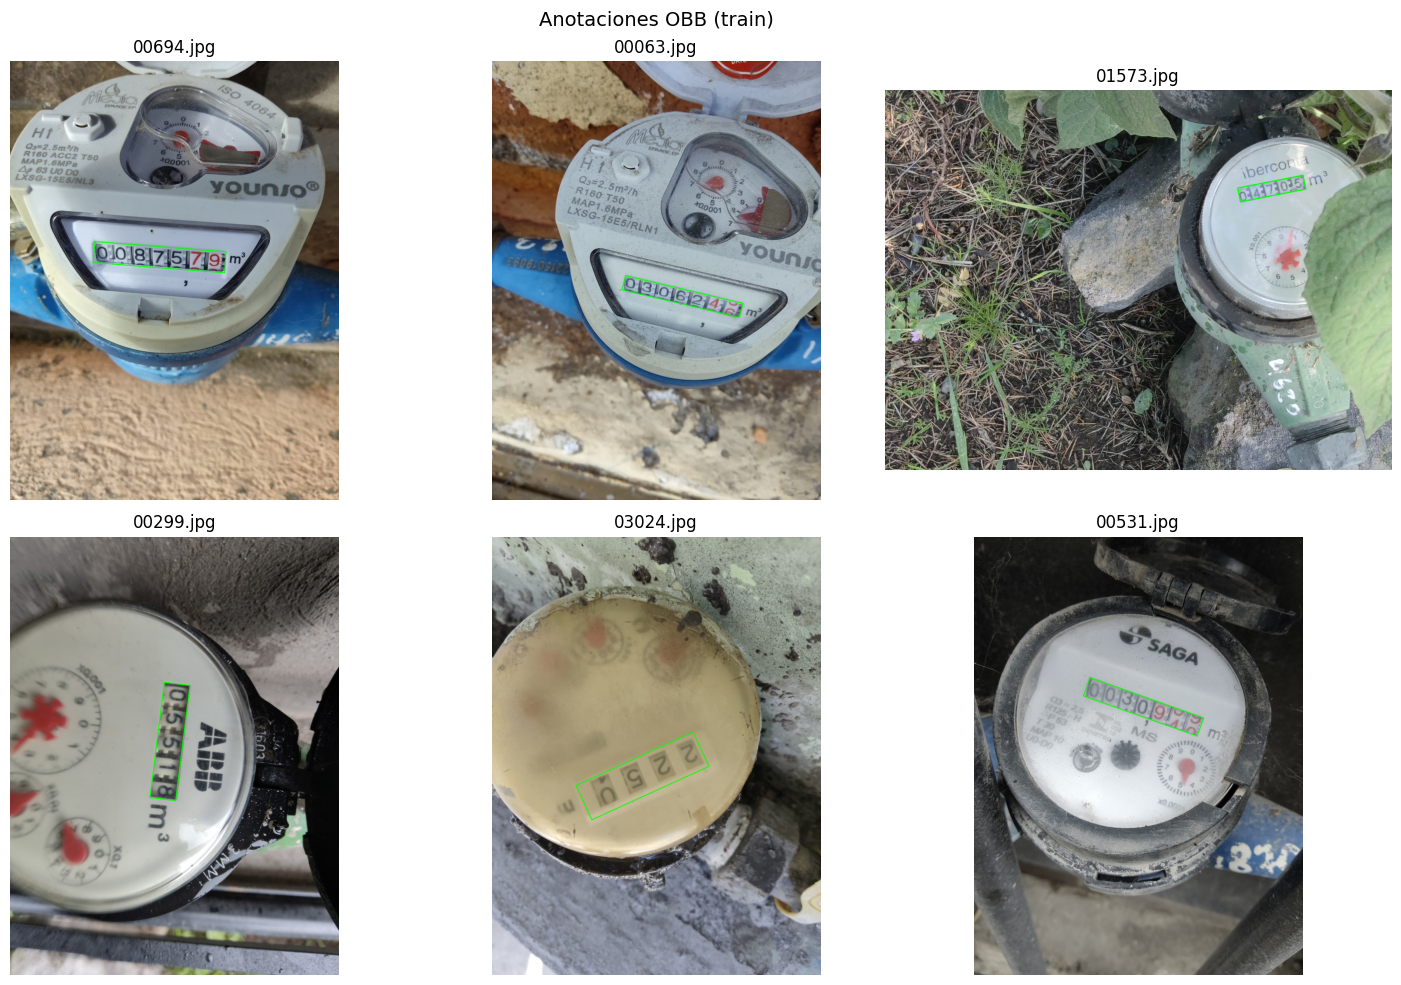

In [ ]:
def plot_obb_annotations(image_path, label_path):
    """Visualiza imagen con anotaciones OBB."""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for ann in f:
                parts = ann.strip().split()
                if len(parts) == 9:
                    coords = [float(x) for x in parts[1:]]
                    points = np.array([(int(coords[i]*w), int(coords[i+1]*h)) for i in range(0, 8, 2)], dtype=np.int32)
                    cv2.polylines(img, [points], True, (0, 255, 0), 2)
    return img

train_imgs = [f for f in os.listdir(TRAIN_IMAGES) if f.lower().endswith(IMG_EXTS)]
sample_viz = random.sample(train_imgs, min(6, len(train_imgs)))
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for idx, img_name in enumerate(sample_viz):
    label_name = os.path.splitext(img_name)[0] + '.txt'
    img_with_obb = plot_obb_annotations(f'{TRAIN_IMAGES}/{img_name}', f'{TRAIN_LABELS}/{label_name}')
    axes.ravel()[idx].imshow(img_with_obb)
    axes.ravel()[idx].set_title(img_name)
    axes.ravel()[idx].axis('off')
plt.suptitle('Anotaciones OBB (train)', fontsize=14)
plt.tight_layout()
plt.show()

### A.3 Análisis de Errores en Validación

Ejecuta inferencia imagen por imagen en val para identificar falsos negativos y detecciones de baja confianza. Puede tardar varios minutos.

In [ ]:
# Análisis de errores en val: FN, baja confianza, detecciones múltiples
if model_best and os.path.exists(VAL_IMAGES):
    val_files = [f for f in os.listdir(VAL_IMAGES) if f.lower().endswith(IMG_EXTS)]

    false_negatives = []
    low_confidence = []
    multiple_detections = []

    for img_name in val_files:
        img_path = f'{VAL_IMAGES}/{img_name}'
        label_path = f'{VAL_LABELS}/{os.path.splitext(img_name)[0]}.txt'

        has_label = os.path.exists(label_path)
        if has_label:
            with open(label_path, 'r') as f:
                has_label = len(f.readlines()) > 0

        results = model_best.predict(img_path, conf=0.25, verbose=False)
        num_det = len(results[0].obb)

        if has_label and num_det == 0:
            false_negatives.append(img_name)
        if num_det > 0 and results[0].obb.conf is not None:
            max_conf = results[0].obb.conf.max().item()
            if max_conf < 0.5:
                low_confidence.append((img_name, max_conf))
        if num_det > 1:
            multiple_detections.append((img_name, num_det))

    print(f"=== ANALISIS DE ERRORES (val, {len(val_files)} imgs) ===")
    print(f"  Falsos negativos:       {len(false_negatives)}")
    print(f"  Baja confianza (<0.5):  {len(low_confidence)}")
    print(f"  Detecciones multiples:  {len(multiple_detections)}")

    if false_negatives:
        print(f"\nFalsos negativos:")
        for fn in false_negatives[:5]:
            print(f"  - {fn}")
    if low_confidence:
        print(f"\nBaja confianza:")
        for lc, conf in sorted(low_confidence, key=lambda x: x[1])[:5]:
            print(f"  - {lc}: {conf:.3f}")
else:
    print("No hay modelo o imagenes de validacion disponibles")

=== ANALISIS DE ERRORES (val, 120 imgs) ===
  Falsos negativos:       0
  Baja confianza (<0.5):  0
  Detecciones multiples:  2
